# Set up

In [1]:
import utility_functions as utils
import GLM
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import numpy.matlib
sns.set_theme()

# Simulate a local population with 100 neurons

In [246]:
nneuron = 100 # ten neurons in each population
nt = 500 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
npadding = 100
ntrial = 100 # 5000 trials in total

time_line = np.arange(nt+npadding)
log_lambda_baseline = np.log(0.03) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = np.zeros(nt+npadding)
# log_lambda_stimulus = 1.2* np.exp(-((time_line-150)/25)**2) + 1.2* np.exp(-((time_line-350)/70)**2)
# stimulus drives the firing rate higher around t=200ms. 

coupling_length = 50
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = 2e-1/nneuron*time_line_coupling*np.exp(-time_line_coupling/10)

history_length = 50
time_line_history = np.arange(history_length)
ground_truth_history = -2.5*np.exp(-time_line_history/5)

In [247]:
# Do simulation
spikes = np.zeros((nt+npadding, nneuron, ntrial))
log_firing_rate = np.zeros((nt+npadding, nneuron, ntrial))

baseline_mat = log_lambda_baseline + log_lambda_stimulus[:,np.newaxis].repeat(nneuron, 1)
coupling_mat = np.flip(ground_truth_coupling_filter)[:,np.newaxis,np.newaxis].repeat(nneuron,1).repeat(nneuron,2)
for i in range(nneuron):
    coupling_mat[:,i,i] = np.flip(ground_truth_history) 

for itrial in tqdm(range(ntrial)):
    spikes_trial, log_firing_rate_trial = GLM.simulate_baseline_coupling(baseline_mat, coupling_mat)
    spikes[:,:,itrial] = spikes_trial
    log_firing_rate[:,:,itrial] = log_firing_rate_trial
    
spikes = spikes[npadding:,:,:]
log_firing_rate = log_firing_rate[npadding:,:,:]

100%|█████████████████████████████████████████| 100/100 [00:18<00:00,  5.33it/s]


Text(0.5, 1.0, 'log firing rate of an example trial')

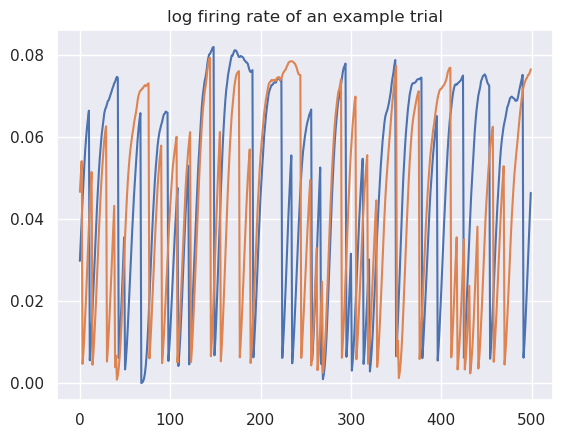

In [249]:
itrial = 0
# plt.subplots(figsize=(5,4))
plt.plot(np.exp(log_firing_rate[:,0,itrial]))
plt.plot(np.exp(log_firing_rate[:,1,itrial]))

plt.title('log firing rate of an example trial')

# Fit pop-GLM with different number of neurons

In [256]:
nselect = 10
st = spikes[:,:nselect,:].mean(axis=1)

model = GLM.PP_GLM(ntrial=ntrial, nt=nt)
model.add_effect("homogeneous_baseline")
model.add_effect("coupling", raw_input=st, num=3, peaks_max=13, nonlinear=0.5)
model.fit(target=st, verbose=False)

Text(0, 0.5, 'spikes/ms')

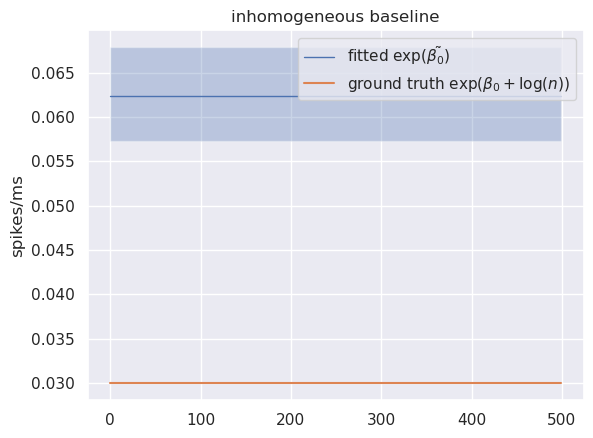

In [257]:
GLM.plot_GLM_one_effect(model, effect_id=0, label=r'fitted $\exp(\tilde{\beta_0})$', 
                        title=r'inhomogeneous baseline')
plt.plot(np.exp(baseline_mat[npadding:,1]), label=r"ground truth $\exp(\beta_0 + \log(n))$")
plt.legend(loc=1)
plt.ylabel("spikes/ms")

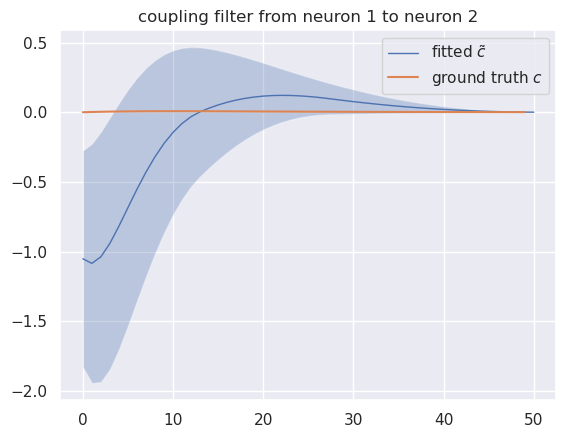

In [258]:
GLM.plot_GLM_one_effect(model, effect_id=1, label=r'fitted $\tilde{c}$', 
                        title=r'coupling filter from neuron 1 to neuron 2')
plt.plot(ground_truth_coupling_filter, label=r"ground truth $c$")
plt.legend()